<a href = "https://github.com/dcruzeneil/dcruzeneil.github.io/blob/main/posts/linear-regression/LinearRegression.py">Implementation of the Linear Regression Algorithm: <i>LinearRegression.py</i></a>

# Introduction to Linear Regression

In our past blog posts, we have mostly dealt with classification - how do we classify a point as part of one group, or the other. However, in this blog post we are going to be dealing with numerical values - how do we make numerical predictions? This means that given a feature matrix - $X \in \mathbb{R}^{n*p}$ - how do we use those features to make numerical predictions about what the value - $y_i$ - will be! In this blog post, we will be dealing with linear regression. This can be visualized as follows: 

<center><img src = "data.png" width=800 height=500/></center>

Based on the above image, if we were to come up with a prediction of what the output value $y_i$ would be, for each point on the x-axis, $x_i$, how do we do that? In this situation, we are dealing with $1$-feature - so, how do we predict the output based on that one feature? The goal of linear regression is to come up with a line which most closely simulates the pattern of the data points. One could visualize a line like this, for instance: 

<center><img src = "data_line.png" width=800 height=500/></center>
    
In this blog post, we will be looking at two ways to find the ideal parameters to formulate the line which closely follows the pattern of the data:

<ol>
    <li><b>Using an Analytical Formula</b>
    <br> When we explicitly set the gradient $\nabla L(w) = 0$ - condition for minimum! We end up getting the formula, $\hat w = (X^TX)^{-1}X^Ty$ - <a href ="https://middlebury-csci-0451.github.io/CSCI-0451/lecture-notes/regression.html">from Lecture Notes (03/08)</a>. Plugging in all the values, results in an explicit formula that churns out the values for $\hat w$. However, the problem with this approach is that it is computationally very expensive. Hence, we have a second way!
    <br><br><li><b>Using Gradient Descent</b>
    <br> We know that the gradient of the loss function is - $\nabla L(w) = 2X^T(Xw-y)$ - <a href="https://middlebury-csci-0451.github.io/CSCI-0451/lecture-notes/regression.html">from Lecture Notes (03/08)</a>. Therefore, we can run a loop for a maximum number of times - <i>max_iter</i> - and on each iteration we can make the update $w^{(t+1)} \leftarrow w^{(t)} - (\alpha * \text{gradient})$. We could check for convergence to add a <i>break</i> statement. Precomputing some values allows us to make this computation more efficient
</ol>

# Implementation of Linear Regression using Analytical Formula

Creating <b>testing</b> and <b>validation</b> data, to see how our i) Analytical Formula approach, and ii) Gradient Descent approach perform, when we are trying to do linear regression!

In [1]:
import numpy as np
from matplotlib import pyplot as plt 

def pad(X):
    return np.append(X, np.ones((X.shape[0], 1)), 1)

def LR_data(n_train = 100, n_val = 100, p_features = 1, noise = .1, w = None):
    if w is None: 
        w = np.random.rand(p_features + 1) + .2
    
    #creating a random X_train matrix with n_train rows - data points - and p_features columns - the features
    X_train = np.random.rand(n_train, p_features)
    y_train = pad(X_train)@w + noise*np.random.randn(n_train)

    X_val = np.random.rand(n_val, p_features)
    y_val = pad(X_val)@w + noise*np.random.randn(n_val)
    
    return X_train, y_train, X_val, y_val

Generating some data using the above method. We are keeping the number of <i>features</i> = $1$, for visualization purposes:

In [14]:
X_train, y_train, X_val, y_val = LR_data(n_train = 100, n_val = 100, p_features = 1, noise = 0.1)

#creating a padded version of X_train and y_train
X_train_padded = pad(X_train)
X_val_padded = pad(X_val)

Now let us plot this data: 

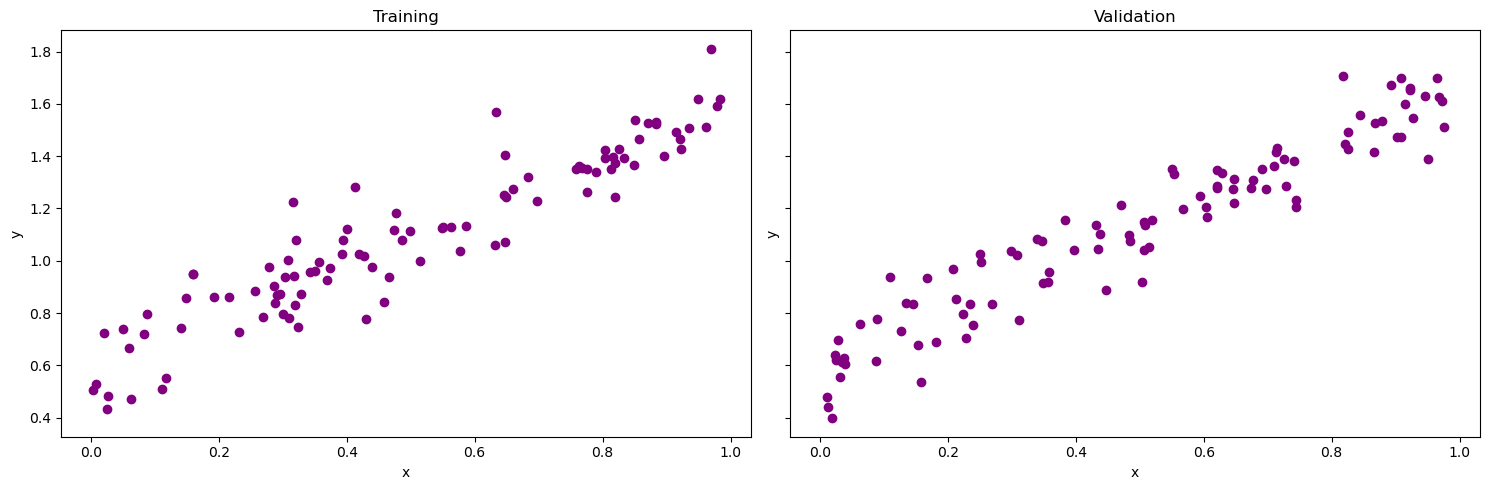

In [15]:
fig, axarr = plt.subplots(1, 2, sharex = True, sharey = True)
plt.rcParams["figure.figsize"] = (15,5)
axarr[0].scatter(X_train, y_train, color="purple")
axarr[1].scatter(X_val, y_val, color="purple")
labs = axarr[0].set(title = "Training", xlabel = "x", ylabel = "y")
labs = axarr[1].set(title = "Validation", xlabel = "x", ylabel = "y")
plt.tight_layout()

Using our <b>Linear Regression</b> implementation to see how well it performs on the <i>training data</i> and <i>validation data</i>! We will use both <b>analytical formula method</b>, and the <b>gradient descent method</b>.

In [16]:
from LinearRegression import LinearRegression

#creating an object of the LinearRegression class
LR = LinearRegression()

#using the analytical formula first
LR.fit_analytic(X_train, y_train)

print(f"Training score = {LR.score(X_train_padded, y_train).round(4)}")
print(f"Validation score = {LR.score(X_val_padded, y_val).round(4)}")

Training score = 0.8754
Validation score = 0.8974


Estimated Weight Vector:

In [17]:
LR.w

array([1.00405436, 0.58991389])

We can visualize the line that the weight vector from our analytical formula forms:

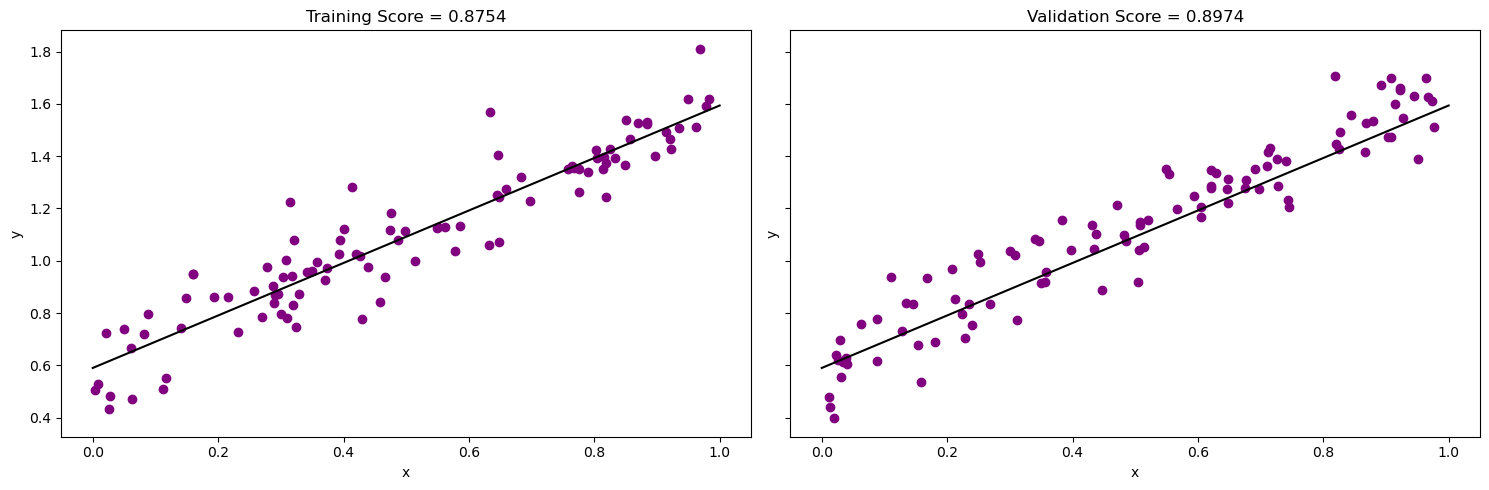

In [18]:
fig, axarr = plt.subplots(1, 2, sharex = True, sharey = True)
plt.rcParams["figure.figsize"] = (15,5)
axarr[0].scatter(X_train, y_train, color = "purple")
LR.draw_line(axarr[0])
axarr[1].scatter(X_val, y_val, color = "purple")
LR.draw_line(axarr[1])
labs = axarr[0].set(title = f"Training Score = {LR.score(X_train_padded, y_train).round(4)}", xlabel = "x", ylabel = "y")
labs = axarr[1].set(title = f"Validation Score = {LR.score(X_val_padded, y_val).round(4)}", xlabel = "x", ylabel = "y")
plt.tight_layout()

# Implementation of Linear Regression using Gradient Descent

In [19]:
LR2 = LinearRegression()
LR2.fit_gradient(X_train, y_train, alpha = 0.0001, max_iter = 10000)

#using the gradient descent method 
print(f"Training score = {LR2.score(X_train_padded, y_train).round(4)}")
print(f"Validation score = {LR2.score(X_val_padded, y_val).round(4)}")

Training score = 0.8754
Validation score = 0.8974


Estimated Weight Vector:

In [20]:
LR2.w

array([1.00405322, 0.5899145 ])

We can visualize the line that the weight vector from our gradient descent method forms:

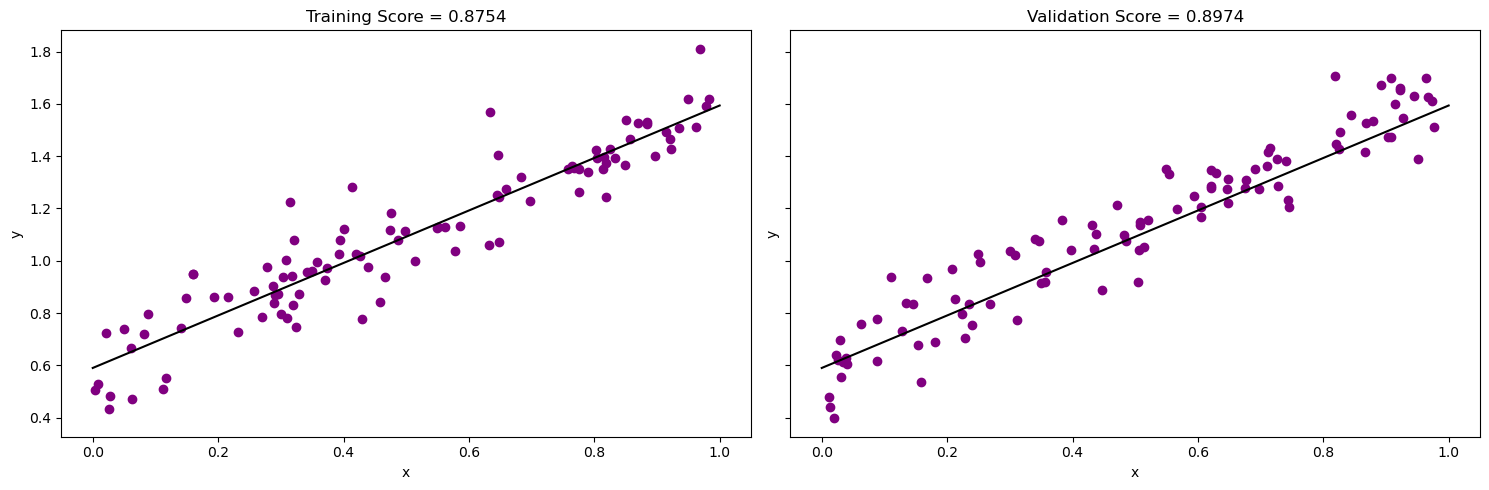

In [21]:
fig, axarr = plt.subplots(1, 2, sharex = True, sharey = True)
plt.rcParams["figure.figsize"] = (15,5)
axarr[0].scatter(X_train, y_train, color = "purple")
LR2.draw_line(axarr[0])
axarr[1].scatter(X_val, y_val, color = "purple")
LR2.draw_line(axarr[1])
labs = axarr[0].set(title = f"Training Score = {LR2.score(X_train_padded, y_train).round(4)}", xlabel = "x", ylabel = "y")
labs = axarr[1].set(title = f"Validation Score = {LR2.score(X_val_padded, y_val).round(4)}", xlabel = "x", ylabel = "y")
plt.tight_layout()

The analytical way gives us the weight vector $\hat w$, which is optimal - mathematically. While, the gradient descent method, iteratively tries to find this optimal solution. However, since our learning rate - $\alpha$ - is small enough, and our maximum number of iterations is large enough, both these approaches give us similar results. This is because the slow learning rate and large number of iterations, truly allow the gradient descent algorithm to find the minimum of the loss function. 

# Visualizing the Increase of Score over time (for Gradient Descent method)

As mentioned in the <a href="https://middlebury-csci-0451.github.io/CSCI-0451/assignments/blog-posts/blog-post-linear-regression.html">instructions for this blog post</a>, the score should increase monotonically in each iteration. Let us see if that is true:

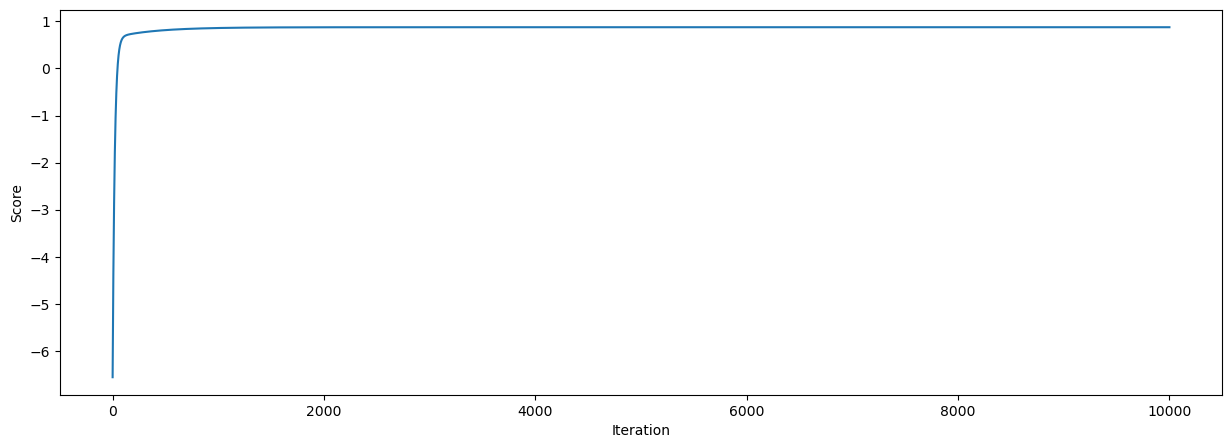

In [22]:
plt.plot(LR2.score_history)
labels = plt.gca().set(xlabel = "Iteration", ylabel = "Score")

Based on the graph, that is indeed true. Therefore, we can be assured that our implementation of Gradient Descent for Linear Regression is working properly. 

# How does Increase in the Number of Features Affect the Score?
So far, for the sake of easy visualization, we have been dealing with a single feature linear regression. That is, we have one value of $X$ - that is $X$ is a $n$x$1$ matrix, and we produce a single numerical output. However, how does an increase in the number of features affect the overall score of our linear regression algorithm? For this purpose, first let us produce data with increasing number of features, and then plot the number of features on the $x$-axis, and the overall score on the $y$-axis. In this blog post, I will find for both: the i) analytical way, and the ii) gradient descent way, how the increase in the number of features affects the overall score on the training data set and the validation data set. 

In [135]:
LR_exp = LinearRegression()
train_score = []
val_score = []
for i in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train = 100, n_val = 100, p_features = i, noise = 0.1)
    LR_exp.fit_analytic(X_train, y_train)
    train_score.append(LR_exp.score(pad(X_train), y_train))
    val_score.append(LR_exp.score(pad(X_val), y_val))

Now that we have our data, let us plot it, to see how the score for the <i>test data</i> and for the <i>validation data</i> changes as the number of features increase:

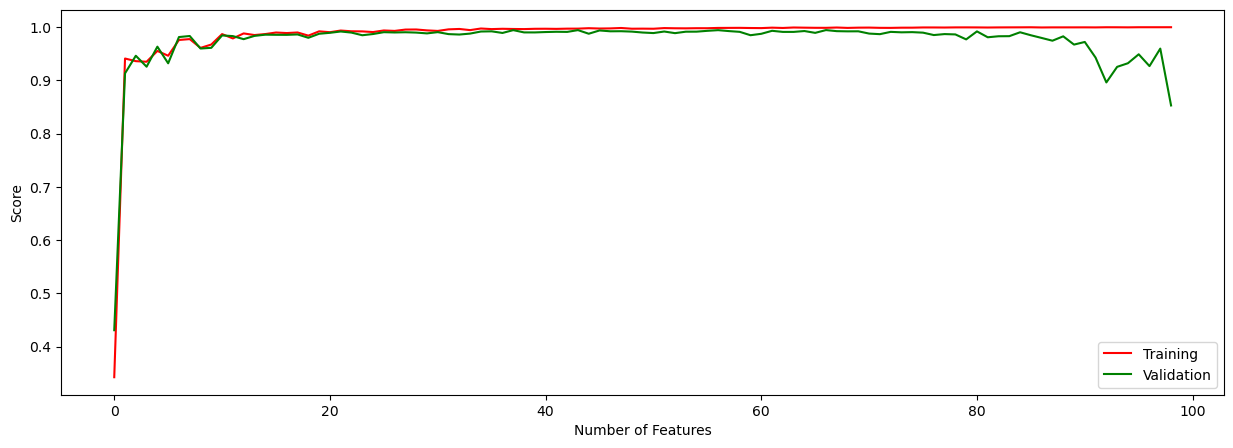

In [137]:
plt.plot(train_score, label = "Training", color = "red")
plt.plot(val_score, label = "Validation", color = "green")
labels = plt.gca().set(xlabel = "Number of Features", ylabel = "Score")
plt.legend()
plt.show()

Now, let us run the same experiment, but this time we will use the <b> gradient descent method </b>:

In [144]:
LR_exp = LinearRegression()
train_score = []
val_score = []
for i in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train = 100, n_val = 100, p_features = i, noise = 0.1)
    LR_exp.fit_gradient(X_train, y_train, alpha = 0.0001, max_iter = 10000)
    train_score.append(LR_exp.score(pad(X_train), y_train))
    val_score.append(LR_exp.score(pad(X_val), y_val))

Now that we have our data, let us plot it, to see how the score for the <i>test data</i> and for the <i>validation data</i> changes as the number of features increase:

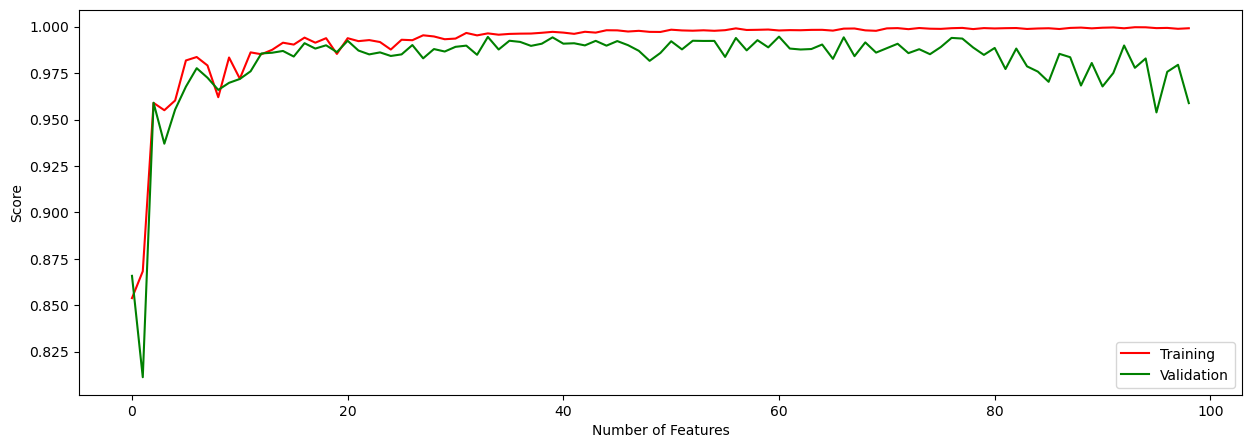

In [145]:
plt.plot(train_score, label = "Training", color = "red")
plt.plot(val_score, label = "Validation", color = "green")
labels = plt.gca().set(xlabel = "Number of Features", ylabel = "Score")
plt.legend()
plt.show()

Therefore, we can see that in both cases: as the number of features keeps on increasing, the training score converges (plateaus) towards a perfect score, however the validaion score starts decreasing after a certain number of features. This is because as the number of features goes up, we start accomodating for <b>noise</b> and therefore - overfitting. One difference, between both the cases is that the analytical method to get the weight vector, seems to be doing relatively better on the validation data as the number of features goes up, compared to the gradient descent method, which struggles to keep up its validation score from early on.  

# Lasso Regularization 

How do we combat overfitting? Regularization. In this part of the blog post, we will implement what is called <i>Lasso Regularization</i>. Using this regularization pushes down the values of the weight vector $w$, this helps us to reduce overfitting. The Lasso Regularization is defined as (check link for source):
<a href="https://middlebury-csci-0451.github.io/CSCI-0451/assignments/blog-posts/blog-post-linear-regression.html">$$L(\mathbf{w}) = \lVert \mathbf{X}\mathbf{w}- \mathbf{y} \rVert_2^2 + \alpha \lVert \mathbf{w}' \rVert_1\;$$</a>

Where $\alpha$ is the term which controls the strength of the regularization. Now, let us implement Lasso Regularization with varying strengths of the regularization. While doing so, let us see how the increase of the number of features affects the <i>training score</i> and the <i>validation score</i>:

In [181]:
from sklearn.linear_model import Lasso

train_score_1 = []
val_score_1 = []
train_score_2  = []
val_score_2 = []
train_score_3 = []
val_score_3 = []

#initializing the Lasso Objects
L1 = Lasso(alpha=0.1)
L2 = Lasso(alpha=0.01)
L3 = Lasso(alpha=0.001)


for i in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train = 100, n_val = 100, p_features = i, noise = 0.1)
    #first object
    L1.fit(X_train, y_train)
    train_score_1.append(L1.score(X_train, y_train))
    val_score_1.append(L1.score(X_val, y_val))
    #second object
    L2.fit(X_train, y_train)
    train_score_2.append(L2.score(X_train, y_train))
    val_score_2.append(L2.score(X_val, y_val))
    #third object
    L3.fit(X_train, y_train)
    train_score_3.append(L3.score(X_train, y_train))
    val_score_3.append(L3.score(X_val, y_val))

Now that we have our data, let us plot it:

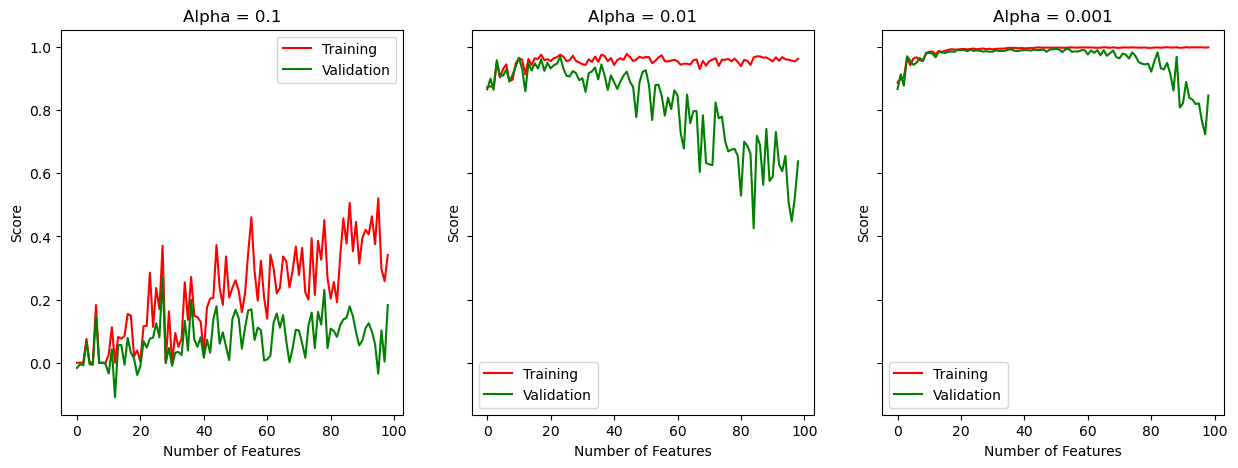

In [182]:
fig, axarr = plt.subplots(1, 3, sharex = True, sharey = True)
plt.rcParams["figure.figsize"] = (15,5)

#first object
axarr[0].plot(train_score_1, label = "Training", color = "red")
axarr[0].plot(val_score_1, label = "Validation", color = "green")
axarr[0].legend()
#second object
axarr[1].plot(train_score_2, label = "Training", color = "red")
axarr[1].plot(val_score_2, label = "Validation", color = "green")
axarr[1].legend()
#third object
axarr[2].plot(train_score_3, label = "Training", color = "red")
axarr[2].plot(val_score_3, label = "Validation", color = "green")
axarr[2].legend()

#setting labels and titles
labels = axarr[0].set(title = "Alpha = 0.1", xlabel = "Number of Features", ylabel = "Score")
labels = axarr[1].set(title = "Alpha = 0.01", xlabel = "Number of Features", ylabel = "Score")
labels = axarr[2].set(title = "Alpha = 0.001", xlabel = "Number of Features", ylabel = "Score")

plt.show()

Now there are a couple of things to unpack here:
<ol>
    <li>When the size of $\alpha$ is large: in the first case, when the size of $\alpha = 0.1$, we can see how the regularization affects the performance. We are unable to find the optimal weight vector due to this heavy regularization. And between $\alpha = 0.01$ and $\alpha = 0.001$, we can see that the latter leads to better performance and convergence. Therefore, the size of $\alpha$ has to be small enough, so that it does not affect our finding of the optimal weight vector. However, it also has to be large enough to have a significant regularizing effect.
    <li>Comparison to Standard Linear Regression: When the value of $\alpha$ is appropriate, the Lasso method seems to lead to faster convergence to accuracy. However, we can again notice the effects of "overfitting" on the <i>validation data</i>. However, this data is surprising to me as the Lasso method does not seem to be doing any better than the Standard Linear Regression when it comes to the <i>validation data</i>, since the whole purpose of the regularization is to avoid overfitting and to get better results on the <i>validation data</i>. 
</ol>

# Additional Experiment: Time Complexity of Analytical Formula and Gradient Descent Method

In this additional section of the blog post, let us try to understand how the increase of the <i>n_train</i> - the number of training data points - affects the time that our two methods take to find the optimal weight vector $w$. For this purpose, we would be experimenting on a bunch of values of <i>n_train</i>, and then computing the time that both the approaches took. Then we will plot the time that both the approaches took versus the number of data points: 

In [188]:
import time

LR_time = LinearRegression()
train_time_analytical = []
train_time_gradient = []
for i in range(100, 5000):
    X_train, y_train, X_val, y_val = LR_data(n_train = i, n_val = i, p_features = 1, noise = 0.1)
    
    start_time = time.time()
    LR_time.fit_analytic(X_train, y_train)
    end_time = time.time()
    train_time_analytical.append(end_time - start_time)
    
    start_time = time.time()
    LR_time.fit_gradient(X_train, y_train, alpha = 0.0001, max_iter = 10000)
    end_time = time.time()
    train_time_gradient.append(end_time - start_time)
    

Now that we have the data, let us plot to see it:

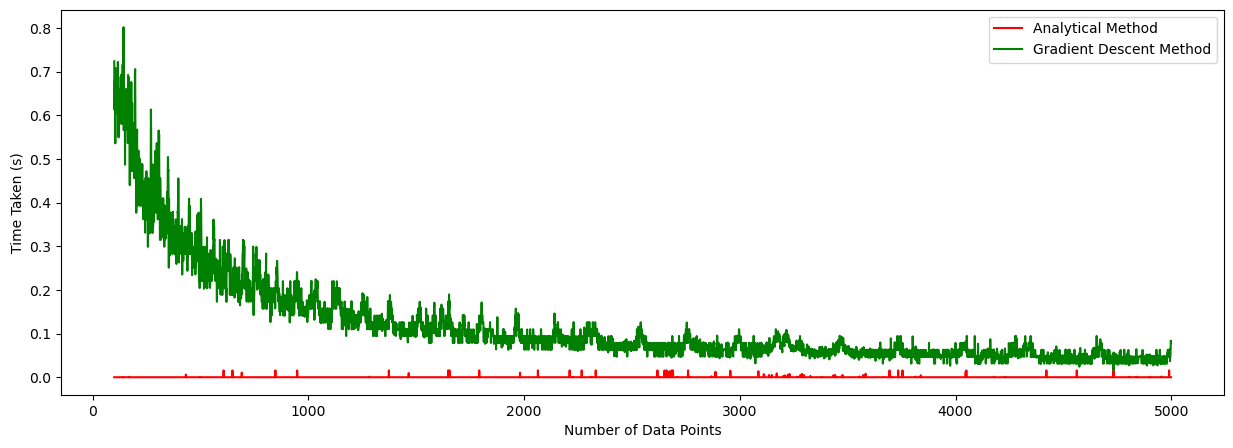

In [190]:
plt.plot(np.arange(100, 5000), train_time_analytical, label = "Analytical Method", color = "red")
plt.plot(np.arange(100, 5000), train_time_gradient, label = "Gradient Descent Method", color = "green")
labels = plt.gca().set(xlabel = "Number of Data Points", ylabel = "Time Taken (s)")
plt.legend()
plt.show()

We can see that the analytical method remains at a constant speed for most of our data points. But, we should also keep in mind that is only going till $5000$ data points (limited by the technical capabilities of this laptop), and in real life all data points are way larger. In that situation the analytical will take a lot of time, as determined by the complexity analysis of the analytical method. This will also be true for the gradient descent method, however its time complexity is lower than the analytical method, so it will take less time. Based on this particular example though, we can see that the time taken by gradient descent kept on decreasing from $100$ data points to $5000$ data points. Upon further research, I found out that this happens because an increased number of data points lead to more stable gradient values - of the loss function - and therefore faster convergence.